### Introduction: Short-Range Repulsive Potentials

When simulating radiation damage via **collision cascades**, interatomic potentials must accurately describe the interaction between atoms at extremely short distances. 

As a Primary Knock-on Atom (PKA) travels through a lattice, it undergoes high-energy collisions. Interaction at these close proximities, leads to a massive increase in energy or **short-range repulsion**. To capture this physics, standard machine-learning or empirical potentials are often "stiffened" by joining them to a repulsive potential (such as the **ZBL** potential).

### "Quasi-Static" Analysis
In this tutorial, we demonstrate the necessity of these repulsive potentials using **quasi-static simulations**. Unlike dynamic MD, where the system evolves over time, a quasi-static approach allows us to manually probe the Potential Energy Surface (PES):

1. **Path Sampling:** An atom is selected and incrementally moved along a specific crystallographic direction.
2. **Energy Monitoring:** We calculate the potential energy at each step and create an energy profile.
3. **The "Repulsive Bump":** As the mobile atom enters the vicinity of a neighbor, a sharp "bump" or peak appears in the energy profile. 

### Comparing Potentials
We will compare two models:
* **The Non-stiffened Potential:** Without repulsive potential, which may fail to capture the sharp energy rise.
* **The Stiffened Potential:** Which correctly models the steep repulsive wall required for realistic radiation damage modeling.

In [2]:
from ase.build import bulk
from ase.io import write, read
import numpy as np
from weas_widget import WeasWidget
import subprocess
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import shutil

In [1]:
def visualize(atoms):
    """
    Visualize the given structure or trajectory.

    Parameters:
        ASE's atoms object.

    Returns:
        'viewer', the visual handle of the given object.
    """
    viewer = WeasWidget()
    viewer.avr.model_style = 0 # ball mode
    viewer.from_ase(atoms)
    viewer.avr.species.settings["Si"].update({"radius": 0.5})
    return viewer


def remove_gap_files():
    """
    Permanently deletes the 'gap_files' folder and its potential files.
    Used for cleaning the workspace before re-running TurboGAP tasks.
    """
    dir_name = 'gap_files'
    if os.path.exists(dir_name):
        shutil.rmtree(dir_name)

In [4]:
# Creating the pristine supercell:
# A [rx,ry,rz] supercell is created for the given "element" with the
# specified crystal structure and lattice constant:

ao = 5.467 #the optimum lattice constant predicted by the poential
element = 'Si'
lattice = 'diamond'
rx, ry, rz = 2, 2, 2 
atoms_pristine = bulk(element, lattice, ao, cubic=True)
atoms_pristine = atoms_pristine.repeat([rx, ry, rz])


In [5]:
def move_atom(atoms, direction, mobile_indx, step_size, n_steps):
    """
    Moves an atom along the given direction. Each step is a frame
    in the trajectory. 

    Parameters:
        atoms:        pristine cell; ASE's Atoms object
        direction:    the direction along which the atom moves
        mobile_indx:  the index of the mobile atom
        step_size:    size of each step in Ang
        n_steps:      number of steps to be taken
    
    returns:
        a list of configurations.
    """
    #normalize the direction to get a unit vector
    unit_vector = direction / np.linalg.norm(direction)
    #displacement vector:
    disp_vector = unit_vector * step_size
    #a list in which all steps are stored
    configs = []
    #walk the atom along the given direction:
    for step in range(n_steps+1):
        new = atoms.copy()
        new.positions[mobile_indx] += (step * disp_vector)
        configs.append(new)
    return configs


# A random direction is selected to move an atom along that direction
# the idea is to monitor the variation of the potential energy of the 
# mobile atom in this direction.
rand_dir = [2, 4, 3]

# Let's take the ato at the origin and move it along the "rand_dir"
# direction, with an "step_size" that is determined by the you!
# The index of the mobile atom is "mobile_indx". 
mobile_indx = 0
step_size = 0.2 #Ang
n_steps = 65


# Generate the trajectory:
configs = move_atom(atoms_pristine, rand_dir, mobile_indx, step_size, n_steps)

# Let's visualize the mobile atom and its trajectory:
viewer = visualize(configs); viewer

# if you want to write down the configs in a single file as frames, uncomment 
# the following line:
#write('configs.xyz', configs)


WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x72a7664b75d0>,))

In [7]:
# Now we perform an static run on each step in the "trajectory".
# to calculate the potential energy of the cell. The calculation
# is done using "turbogap predict". 

def create_tgap_input(cell_name, pot_name):
    """
    Creates the 'input' file for TurboGAP in the working 
    directory.

    Paramters:
        cell_name: the structure file with xyz format.
    """
    input_str = f"""
    ! Species-specific info
    atoms_file = '{cell_name}'
    pot_file = 'gap_files/{pot_name}'
    n_species = 1
    species = Si
    masses = 28.09   
    write_thermo = 1
    """
    f = open('input', 'w')
    f.write(input_str)
    f.close()


# to retrieve the energy of each step, the "trajectory_out.xyz" file
# will be used which is generated by TurboGAP.
def read_ePot():
    """
    Reads in the "trajectory_out.xyz" and gets the 
    potential energy ("energy=") from of it.
    """
    atoms = read('trajectory_out.xyz')
    epot = atoms.get_potential_energy()
    return epot


def run_turbogap(n_cores):
    """
    Runs the TurboGAP code in 'predict' mode.
    """
    command = ['mpirun', '-np', str(n_cores), 'turbogap', 'predict']
    result = subprocess.run(command, check=True)
    

In [8]:
# copy the stiffened potentil to "gap_files":
remove_gap_files()
shutil.copytree('gap_files_stiffened', 'gap_files', dirs_exist_ok=True)


# Now, the following function loops over each step and calculate its energy:
def calc_epot_configs(config_list, pot_name):
    """
    Loops over the configs in the 'config_list', calculates their
    potential energy.

    Returns:
        An array containing the potential energy of each config.
    """
    epots = []
    for i, config in enumerate(tqdm(configs, desc="Step")):
        # export the xyz file of the config:
        outname = 'step.xyz'
        write(outname, config)
        # write the input file:
        create_tgap_input(outname, pot_name)
        # run TurboGAP (predict):
        run_turbogap(n_cores=4)
        # get the energy:
        epot = read_ePot()
        epots.append(epot)
    return epots


# and the energies of all steps:
epots = calc_epot_configs(configs, 'Si.ZBL-stiff.TGAP.gap')


# Subtracting the energy of the pristine cell to get the delta_energy
epots -= epots[0]


# plotting the "energy difference" along the given direction:
plt.plot(epots, 'o-', markersize=4, linewidth=1.0, label='ZBL-stiffened potential')
plt.xlabel('step')
plt.ylabel('Energy difference (eV)')
plt.legend()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'gap_files_stiffened'

In [105]:
# Now, we redo the same process, but with non-stiffened version of the potential.
# In other words, the potential does not have a repulsive potential. 

# copy the non-stiffened potentil to "gap_files":
remove_gap_files
shutil.copytree('gap_files_nonStiff', 'gap_files', dirs_exist_ok=True)

# epots from the non-stiffened potential:
epots_ns = calc_epot_configs(configs, 'silicon.gap')

# Subtracting the energy of the pristine cell to get the delta_energy
epots_ns -= epots_ns[0]

# plotting the "energy difference" along the given direction:
plt.plot(epots_ns, 'o-', markersize=4, linewidth=1.0, label='Non-stiffened potential')
plt.xlabel('step')
plt.ylabel('Energy difference (eV)')
plt.legend()
plt.show()

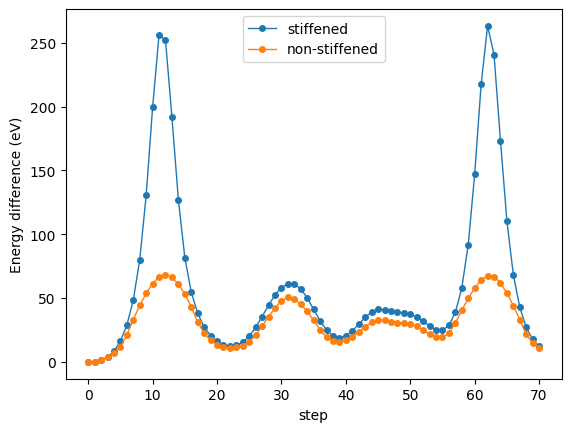

In [108]:
# in the third plot, we compare the prediction of the stiffened and non-stiffened 
# potentials, and the influence of repulsive potential would be evident:
plt.plot(epots, 'o-', markersize=4, linewidth=1.0, label='stiffened')
plt.plot(epots_ns, 'o-', markersize=4, linewidth=1.0, label='non-stiffened')
plt.xlabel('step')
plt.ylabel('Energy difference (eV)')
plt.legend()
plt.show()
